In [1]:
import cv2
import numpy as np
import mediapipe as mp

from utils import CvFpsCalc
from model import KeyPointClassifier
import os
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
import copy

2025-05-14 13:52:55.938731: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-14 13:52:55.957181: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747205575.977699   59526 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747205575.983915   59526 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747205576.000631   59526 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
CLASS_NAMES = ['nothing','down','turn_left','turn_right','up']
CLASS_NAMES.sort()
TEST_DATA_PATH = 'test'
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(
        static_image_mode='true',
        max_num_hands=1,
        min_detection_confidence=0.7,
        min_tracking_confidence=0.5,
)
keypoint_classifier = KeyPointClassifier()

I0000 00:00:1747205579.228204   59526 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1747205579.231503   59625 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 24.2.8-1ubuntu1~24.04.1), renderer: Mesa Intel(R) UHD Graphics (TGL GT1)
/home/panha/Desktop/Rupp/Year_4/semester_2/thesis/hand_gesture_recognition_code/third_approach/env/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [3]:
def calc_landmark_list(image, landmarks):
    image_width, image_height = image.shape[1], image.shape[0]

    landmark_point = []

    # Keypoint
    for _, landmark in enumerate(landmarks.landmark):
        landmark_x = min(int(landmark.x * image_width), image_width - 1)
        landmark_y = min(int(landmark.y * image_height), image_height - 1)
        # landmark_z = landmark.z

        landmark_point.append([landmark_x, landmark_y])

    return landmark_point

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [4]:
def pre_process_landmark(landmark_list):
    temp_landmark_list = copy.deepcopy(landmark_list)

    # Convert to relative coordinates
    base_x, base_y = 0, 0
    for index, landmark_point in enumerate(temp_landmark_list):
        if index == 0:
            base_x, base_y = landmark_point[0], landmark_point[1]

        temp_landmark_list[index][0] = temp_landmark_list[index][0] - base_x
        temp_landmark_list[index][1] = temp_landmark_list[index][1] - base_y

    # Convert to a one-dimensional list
    temp_landmark_list = list(
        itertools.chain.from_iterable(temp_landmark_list))

    # Normalization
    max_value = max(list(map(abs, temp_landmark_list)))

    def normalize_(n):
        return n / max_value

    temp_landmark_list = list(map(normalize_, temp_landmark_list))

    return temp_landmark_list

In [5]:
class_names = sorted(os.listdir(TEST_DATA_PATH))

y_true = []
y_pred = []

# Loop through each class directory
for class_name in class_names:
    class_dir = os.path.join(TEST_DATA_PATH, class_name)
    
    for filename in os.listdir(class_dir):
        img_path = os.path.join(class_dir, filename)
        image = cv2.imread(img_path)
        
        debug_image = copy.deepcopy(image)

        # Detection implementation #############################################################
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        image.flags.writeable = False
        results = hands.process(image)
        image.flags.writeable = True

        # Skip if no hands detected
        if results.multi_hand_landmarks is None:
            print(f"No hands detected in {img_path}")
            continue

        # Loop through detected hands (usually one in classification tasks)
        for hand_landmarks, handedness in zip(results.multi_hand_landmarks,results.multi_handedness):
            # Step 1: Get landmark list
            landmark_list = calc_landmark_list(debug_image, hand_landmarks)

            # Step 2: Pre-process
            pre_processed_landmark_list = pre_process_landmark(landmark_list)

            # Step 3: Classify
            hand_sign_id = keypoint_classifier(pre_processed_landmark_list)

            # Step 4: Append results
            y_true.append(class_name)
            y_pred.append(CLASS_NAMES[hand_sign_id])
            break  # Only classify one hand per image

W0000 00:00:1747205579.274735   59619 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1747205579.299953   59617 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1747205579.313442   59610 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


Classification Report:
              precision    recall  f1-score   support

        down       0.00      0.00      0.00         5
     nothing       0.00      0.00      0.00         5
   turn_left       1.00      1.00      1.00         5
  turn_right       1.00      1.00      1.00         5
          up       0.50      1.00      0.67         5

    accuracy                           0.60        25
   macro avg       0.50      0.60      0.53        25
weighted avg       0.50      0.60      0.53        25



/home/panha/Desktop/Rupp/Year_4/semester_2/thesis/hand_gesture_recognition_code/third_approach/env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/panha/Desktop/Rupp/Year_4/semester_2/thesis/hand_gesture_recognition_code/third_approach/env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/panha/Desktop/Rupp/Year_4/semester_2/thesis/hand_gesture_recognition_code/third_approach/env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarnin

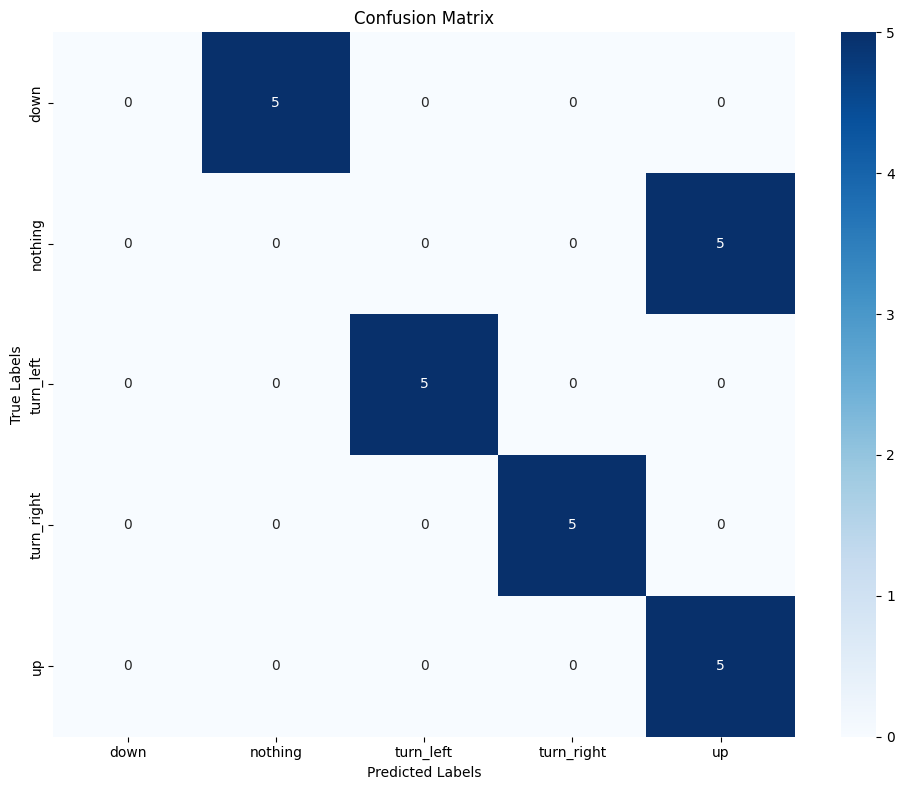

In [6]:
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred, labels=class_names)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

In [7]:
import os
import cv2
import time

class_names = sorted(os.listdir(TEST_DATA_PATH))

y_true = []
y_pred = []

start_time = time.time()

# Loop through each class directory
for class_name in class_names:
    class_dir = os.path.join(TEST_DATA_PATH, class_name)
    
    for filename in os.listdir(class_dir):
        img_path = os.path.join(class_dir, filename)
        image = cv2.imread(img_path)
        
        debug_image = copy.deepcopy(image)

        # Detection implementation #############################################################
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        image.flags.writeable = False
        results = hands.process(image)
        image.flags.writeable = True

        # Skip if no hands detected
        if results.multi_hand_landmarks is None:
            print(f"No hands detected in {img_path}")
            continue

        # Loop through detected hands (usually one in classification tasks)
        for hand_landmarks, handedness in zip(results.multi_hand_landmarks,results.multi_handedness):
            # Step 1: Get landmark list
            landmark_list = calc_landmark_list(debug_image, hand_landmarks)

            # Step 2: Pre-process
            pre_processed_landmark_list = pre_process_landmark(landmark_list)

            # Step 3: Classify
            hand_sign_id = keypoint_classifier(pre_processed_landmark_list)

            # Step 4: Append results
            y_true.append(class_name)
            y_pred.append(CLASS_NAMES[hand_sign_id])
            break  # Only classify one hand per image
end_time = time.time()
elapsed_time = end_time - start_time

print(f"\nTotal prediction time for {len(y_true)} images: {elapsed_time:.2f} seconds")
print(f"Average prediction time per image: {elapsed_time / len(y_true):.4f} seconds")


Total prediction time for 25 images: 0.96 seconds
Average prediction time per image: 0.0385 seconds
